In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/oxford-iiit-pet-noses

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/oxford-iiit-pet-noses


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.optim as optim
import numpy as np
from tqdm import tqdm
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
class SnoutNet(nn.Module):
    def __init__(self):
        super(SnoutNet, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, padding=1)

        self.conv2 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, padding=1)

        self.conv3 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=2)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2, padding=1)

        self.fc1 = nn.Linear(4 * 4 * 256, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        x = self.pool3(x)

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

model = SnoutNet()
dummy_input = torch.randn(1, 3, 227, 227)
output = model(dummy_input)
print("Output shape:", output.shape)
print("Output tensor:", output)

Output shape: torch.Size([1, 2])
Output tensor: tensor([[ 0.0250, -0.0416]], grad_fn=<AddmmBackward0>)


In [21]:
# Dataset
class PetNoseDataset(Dataset):
    def __init__(self, images_dir, annotations_file, transform=None, target_size=(227, 227)):
        self.images_dir = images_dir
        self.transform = transform
        self.target_size = target_size
        self.annotations = []
        with open(annotations_file, 'r') as f:
            for line in f.readlines():
                image_name, coord_str = line.strip().split(',', 1)
                coord = tuple(map(int, coord_str.strip('"()').split(',')))
                self.annotations.append((image_name, coord))

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        image_name, coord = self.annotations[idx]
        img_path = os.path.join(self.images_dir, image_name)
        image = Image.open(img_path).convert('RGB')
        orig_width, orig_height = image.size
        if self.transform:
            image = self.transform(image)
        x, y = coord
        x_scaled = x * (self.target_size[0] / orig_width)
        y_scaled = y * (self.target_size[1] / orig_height)
        label = torch.tensor([x_scaled, y_scaled], dtype=torch.float32)
        return image, label

/content/oxford-iiit-pet-noses
Batch images shape: torch.Size([16, 3, 227, 227])
Batch labels: tensor([[ 83.9900, 135.6546],
        [ 95.1497, 105.3280],
        [112.5920, 133.7787],
        [103.5120, 138.8564],
        [ 71.7320, 122.2773],
        [173.8192,  67.1006],
        [113.8027,  92.6160],
        [122.5800,  98.8711],
        [175.6980,  83.2664],
        [115.5636,  93.8267],
        [ 91.1783,  63.9323],
        [ 81.2660, 108.4481],
        [143.7667,  79.7022],
        [111.6840, 125.9093],
        [101.6771,  96.4750],
        [129.1662, 109.4140]])


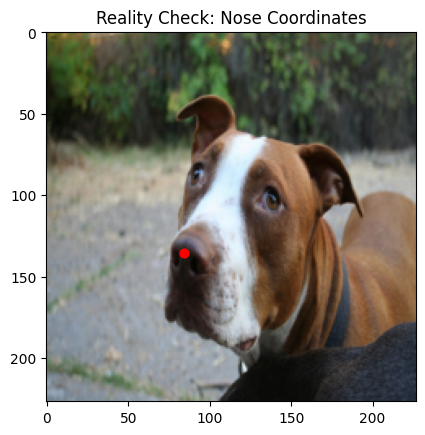

In [22]:
# Transforms
transform_no_aug = transforms.Compose([
    transforms.Resize((227,227)),
    transforms.ToTensor()
])

transform_aug = transforms.Compose([
    transforms.Resize((227,227)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

# Copy dataset from Drive
!cp -r /content/drive/MyDrive/oxford-iiit-pet-noses /content/
%cd /content/oxford-iiit-pet-noses

images_dir = "images-original/images"
train_file = "train_noses.txt"
test_file = "test_noses.txt"

# Train/test dataset aug vs no aug
train_dataset_no_aug = PetNoseDataset(images_dir, train_file, transform=transform_no_aug, target_size=(227,227))
test_dataset_no_aug  = PetNoseDataset(images_dir, test_file, transform=transform_no_aug, target_size=(227,227))

train_dataset_flex_aug = PetNoseDataset(images_dir, train_file, transform=transform_aug, target_size=(227,227))
test_dataset_flex_aug  = PetNoseDataset(images_dir, test_file, transform=transform_no_aug, target_size=(227,227))

# DataLoaders
batch_size = 16

train_loader_no_aug = DataLoader(train_dataset_no_aug, batch_size=batch_size, shuffle=True)
test_loader_no_aug  = DataLoader(test_dataset_no_aug, batch_size=batch_size, shuffle=False)
train_loader_aug = DataLoader(train_dataset_flex_aug, batch_size=batch_size, shuffle=True)
test_loader_aug  = DataLoader(test_dataset_flex_aug, batch_size=batch_size, shuffle=False)

# plot image coords to test
for images, labels in train_loader_no_aug:
    print("Batch images shape:", images.shape)
    print("Batch labels:", labels)

    img = images[0].permute(1, 2, 0).numpy()
    x, y = labels[0]

    plt.imshow(img)
    plt.scatter(x, y, c='r', s=40)
    plt.title("Reality Check: Nose Coordinates")
    plt.show()
    break


In [7]:
# Pretrained models
class AlexNetNose(nn.Module):
    def __init__(self, pretrained=True):
        super(AlexNetNose, self).__init__()
        self.alex = models.alexnet(pretrained=pretrained)
        self.alex.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 1024),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 2)
        )
    def forward(self, x):
        return self.alex(x)

class VGG16Nose(nn.Module):
    def __init__(self, pretrained=True):
        super(VGG16Nose, self).__init__()
        vgg = models.vgg16(pretrained=pretrained)
        self.features = vgg.features
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Linear(512*7*7, 4096),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(4096, 1024),
            nn.ReLU(),
            nn.Linear(1024, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x
vgg_test = VGG16Nose()
print(vgg_test)
dummy = torch.randn(1, 3, 227, 227)
output = vgg_test(dummy)
print("Output shape:", output.shape)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG16Nose(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dila

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(torch.cuda.get_device_name(0))

cuda
NVIDIA A100-SXM4-40GB


In [25]:
def train_model(model, train_loader, test_loader, device, num_epochs=10, lr=1e-5):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0
        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        val_loss_total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss_total += criterion(outputs, labels).item() * images.size(0)
        val_loss = val_loss_total / len(test_loader.dataset)
        val_losses.append(val_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return model, train_losses, val_losses

In [11]:
# SnoutNet
snout_no_aug, snout_train_loss_no_aug, snout_val_loss_no_aug = train_model(
    SnoutNet(), train_loader_no_aug, test_loader_no_aug, device
)
torch.save(snout_no_aug.state_dict(), "snoutnet_no_aug.pth")
torch.save(snout_train_loss_no_aug, "snout_train_loss_no_aug.pth")
torch.cuda.empty_cache()

snout_aug, snout_train_loss_aug, snout_val_loss_aug = train_model(
    SnoutNet(), train_loader_aug, test_loader_no_aug, device
)
torch.save(snout_aug.state_dict(), "snoutnet_aug.pth")
torch.save(snout_train_loss_aug, "snout_train_loss_aug.pth")
torch.cuda.empty_cache()

NameError: name 'snout_no_aug' is not defined

In [42]:
# AlexNet
alex_no_aug, alex_train_loss_no_aug, alex_val_loss_no_aug = train_model(
    AlexNetNose(), train_loader_no_aug, test_loader_no_aug, device
)
torch.save(alex_no_aug.state_dict(), "alexnet_no_aug.pth")
torch.save(alex_train_loss_no_aug, "alex_train_loss_no_aug.pth")
torch.cuda.empty_cache()

alex_aug, alex_train_loss_aug, alex_val_loss_aug = train_model(
    AlexNetNose(), train_loader_aug, test_loader_no_aug, device
)
torch.save(alex_aug.state_dict(), "alexnet_aug.pth")
torch.save(alex_train_loss_aug, "alex_train_loss_aug.pth")
torch.cuda.empty_cache()

AttributeError: 'list' object has no attribute 'alexnet'

In [26]:
# VGG16
vgg_no_aug, vgg_train_loss_no_aug, vgg_val_loss_no_aug = train_model(
    VGG16Nose(), train_loader_no_aug, test_loader_no_aug, device
)
torch.save(vgg_no_aug.state_dict(), "vgg16_no_aug.pth")
torch.save(vgg_train_loss_no_aug, "vgg_train_loss_no_aug.pth")
torch.cuda.empty_cache()

vgg_aug, vgg_train_loss_aug, vgg_val_loss_aug = train_model(
    VGG16Nose(), train_loader_aug, test_loader_no_aug, device
)
torch.save(vgg_aug.state_dict(), "vgg16_aug.pth")
torch.save(vgg_train_loss_aug, "vgg_train_loss_aug.pth")
torch.cuda.empty_cache()

100%|██████████| 344/344 [00:39<00:00,  8.77it/s]


Epoch [1/10] Train Loss: 1360.9090 | Val Loss: 280.3495


100%|██████████| 344/344 [00:39<00:00,  8.78it/s]


Epoch [2/10] Train Loss: 209.3482 | Val Loss: 193.7978


100%|██████████| 344/344 [00:39<00:00,  8.79it/s]


...

Epoch [8/10] Train Loss: 40.3743 | Val Loss: 98.5541


100%|██████████| 344/344 [00:46<00:00,  7.34it/s]


Epoch [9/10] Train Loss: 35.0976 | Val Loss: 97.4214


100%|██████████| 344/344 [00:46<00:00,  7.35it/s]


Epoch [10/10] Train Loss: 32.2593 | Val Loss: 124.8473


In [27]:
# Individual model predictions
def individual_model_predict(model, loader, device, model_name):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    distances = torch.sqrt(torch.sum((all_preds - all_labels)**2, dim=1)).numpy()

    # Sort distances
    sorted_indices = np.argsort(distances)
    best_4 = distances[sorted_indices[:4]]
    worst_4 = distances[sorted_indices[-4:]]

    print(f"\n{model_name}:")
    print(f"Overall - Min: {distances.min():.2f} | Max: {distances.max():.2f} | Mean: {distances.mean():.2f} | Std: {distances.std():.2f}")
    print(f"4 Best  - Min: {best_4.min():.2f} | Max: {best_4.max():.2f} | Mean: {best_4.mean():.2f} | Std: {best_4.std():.2f}")
    print(f"4 Worst - Min: {worst_4.min():.2f} | Max: {worst_4.max():.2f} | Mean: {worst_4.mean():.2f} | Std: {worst_4.std():.2f}")

# Ensemble predictions
def ensemble_predict_detailed(models, loader, device, model_name="Ensemble"):
    for m in models:
        m.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            preds = sum([m(images) for m in models]) / len(models)
            all_preds.append(preds.cpu())
            all_labels.append(labels)

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    distances = torch.sqrt(torch.sum((all_preds - all_labels)**2, dim=1)).numpy()

    # Sort distances
    sorted_indices = np.argsort(distances)
    best_4 = distances[sorted_indices[:4]]
    worst_4 = distances[sorted_indices[-4:]]

    print(f"\n{model_name}:")
    print(f"Overall - Min: {distances.min():.2f} | Max: {distances.max():.2f} | Mean: {distances.mean():.2f} | Std: {distances.std():.2f}")
    print(f"4 Best  - Min: {best_4.min():.2f} | Max: {best_4.max():.2f} | Mean: {best_4.mean():.2f} | Std: {best_4.std():.2f}")
    print(f"4 Worst - Min: {worst_4.min():.2f} | Max: {worst_4.max():.2f} | Mean: {worst_4.mean():.2f} | Std: {worst_4.std():.2f}")

print("="*80)
print("NO AUGMENTATION")
print("="*80)

# Test individual models without augmentation
individual_model_predict(snout_no_aug, test_loader_no_aug, device, "SnoutNet (No Aug)")
individual_model_predict(alex_no_aug, test_loader_no_aug, device, "SnoutNet-A / AlexNet (No Aug)")
individual_model_predict(vgg_no_aug, test_loader_no_aug, device, "SnoutNet-V / VGG16 (No Aug)")

# Ensemble without augmentation
ensemble_models_no_aug = [snout_no_aug, alex_no_aug, vgg_no_aug]
ensemble_predict_detailed(ensemble_models_no_aug, test_loader_no_aug, device, "SnoutNet-Ensemble (No Aug)")

print("\n" + "="*80)
print("WITH AUGMENTATION")
print("="*80)

# Test individual models with augmentation
individual_model_predict(snout_aug, test_loader_no_aug, device, "SnoutNet (With Aug)")
individual_model_predict(alex_aug, test_loader_no_aug, device, "SnoutNet-A / AlexNet (With Aug)")
individual_model_predict(vgg_aug, test_loader_no_aug, device, "SnoutNet-V / VGG16 (With Aug)")

# Ensemble with augmentation
ensemble_models_aug = [snout_aug, alex_aug, vgg_aug]
ensemble_predict_detailed(ensemble_models_aug, test_loader_no_aug, device, "SnoutNet-Ensemble (With Aug)")

NO AUGMENTATION

SnoutNet (No Aug):
Overall - Min: 0.94 | Max: 136.51 | Mean: 31.31 | Std: 21.45
4 Best  - Min: 0.94 | Max: 3.50 | Mean: 2.56 | Std: 0.96
4 Worst - Min: 117.05 | Max: 136.51 | Mean: 126.60 | Std: 8.26

SnoutNet-A / AlexNet (No Aug):
Overall - Min: 0.25 | Max: 139.39 | Mean: 19.28 | Std: 17.34
4 Best  - Min: 0.25 | Max: 0.80 | Mean: 0.56 | Std: 0.20
4 Worst - Min: 100.52 | Max: 139.39 | Mean: 116.48 | Std: 14.92

SnoutNet-V / VGG16 (No Aug):
Overall - Min: 0.10 | Max: 82.49 | Mean: 10.72 | Std: 9.83
4 Best  - Min: 0.10 | Max: 0.52 | Mean: 0.32 | Std: 0.16
4 Worst - Min: 71.24 | Max: 82.49 | Mean: 74.46 | Std: 4.66

SnoutNet-Ensemble (No Aug):
Overall - Min: 0.19 | Max: 111.23 | Mean: 16.52 | Std: 14.10
4 Best  - Min: 0.19 | Max: 0.83 | Mean: 0.52 | Std: 0.23
4 Worst - Min: 84.33 | Max: 111.23 | Mean: 95.52 | Std: 9.79

WITH AUGMENTATION

SnoutNet (With Aug):
Overall - Min: 1.57 | Max: 141.81 | Mean: 37.59 | Std: 22.16
4 Best  - Min: 1.57 | Max: 2.73 | Mean: 2.23 | Std: 0

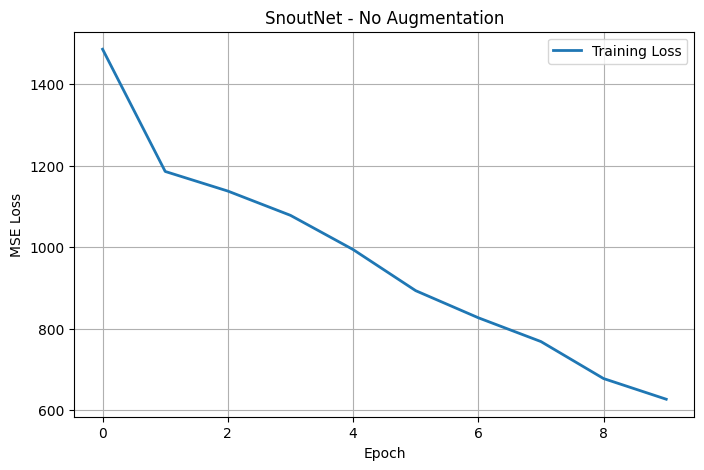

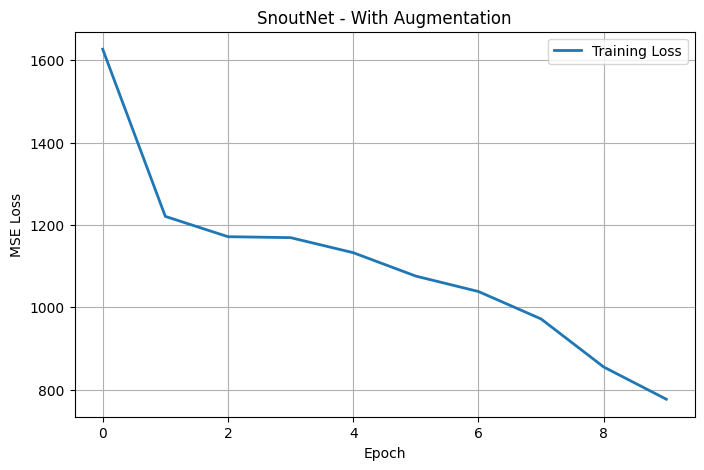

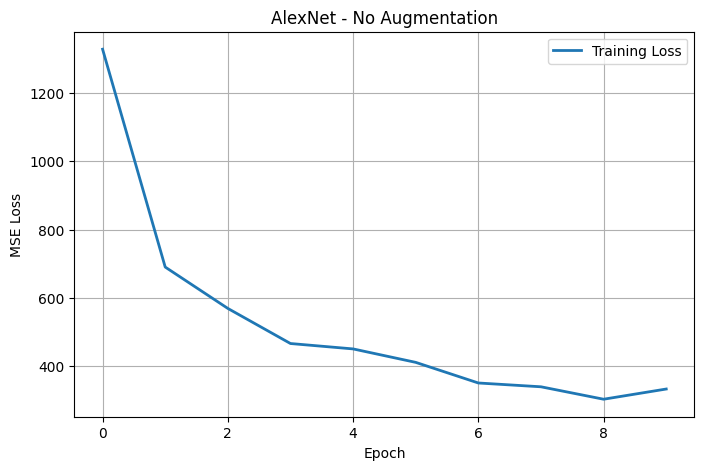

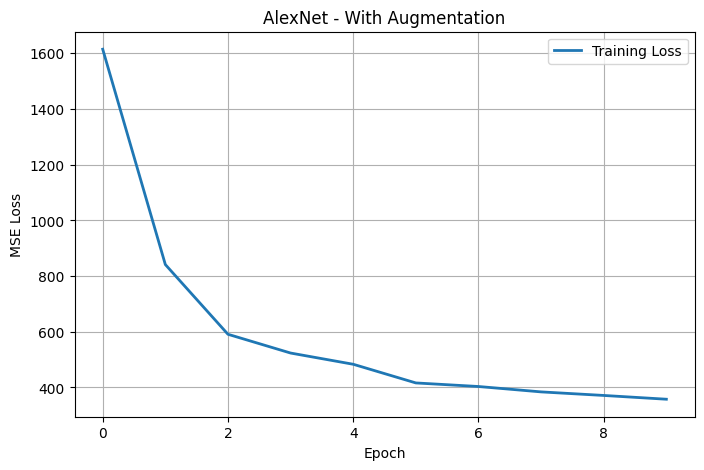

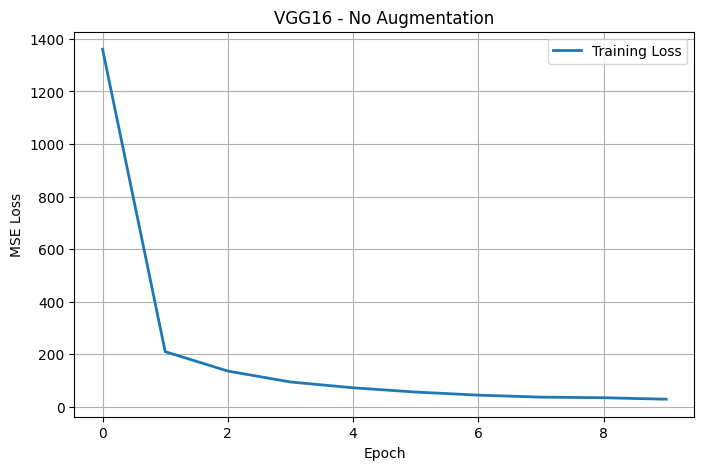

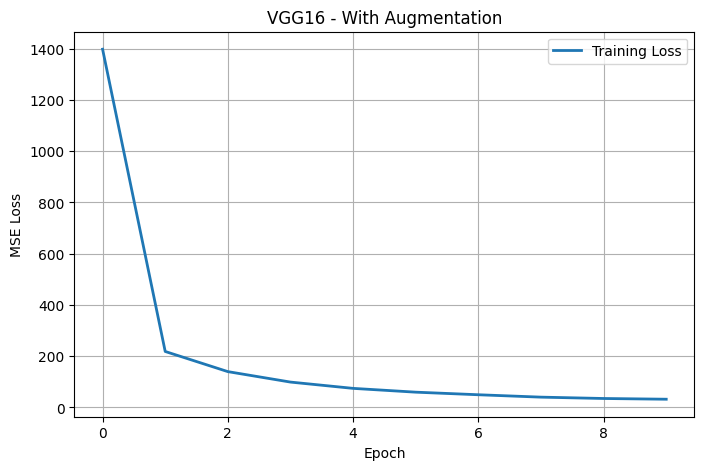

In [28]:
# Load all saved losses
snout_train_loss_no_aug = torch.load('snout_train_loss_no_aug.pth')
snout_train_loss_aug = torch.load('snout_train_loss_aug.pth')

alex_train_loss_no_aug = torch.load('alex_train_loss_no_aug.pth')
alex_train_loss_aug = torch.load('alex_train_loss_aug.pth')

vgg_train_loss_no_aug = torch.load('vgg_train_loss_no_aug.pth')
vgg_train_loss_aug = torch.load('vgg_train_loss_aug.pth')

# Now plot
def plot_losses(train_losses, title):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Training Loss', linewidth=2)
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_losses(snout_train_loss_no_aug, "SnoutNet - No Augmentation")
plot_losses(snout_train_loss_aug, "SnoutNet - With Augmentation")

plot_losses(alex_train_loss_no_aug, "AlexNet - No Augmentation")
plot_losses(alex_train_loss_aug, "AlexNet - With Augmentation")

plot_losses(vgg_train_loss_no_aug, "VGG16 - No Augmentation")
plot_losses(vgg_train_loss_aug, "VGG16 - With Augmentation")